In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))
from srlib.dataset.loading import load_edsr_dataset
from srlib.dataset.visualization import plot_patch_pairs
from srlib.deep_learning.edsr import EDSR
from srlib.constants import (
    CLASS_LABELS_PATH,
    EDSR_PATCH_SIZE,
    EDSR_SCALE_FACTOR,
    EDSR_STRIDE,
    HR_ROOT,
    LR_ROOT,
)

In [2]:
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_edsr_dataset(
    HR_ROOT,
    LR_ROOT,
    CLASS_LABELS_PATH,
    patch_size=EDSR_PATCH_SIZE,
    stride=EDSR_STRIDE,
    scale_factor=EDSR_SCALE_FACTOR,
)


 EDSR dataset | patch 48, stride 24, x2
  images    358 indexed -> 179 kept -> 144 train / 17 val / 18 test


  patches   11,664 train / 1,377 val / 1,458 test   of 48 x 48 x 3
  memory    1.57 GB


  range     X [0.0000, 1.0000]   Y [0.0000, 1.0000]
  done in 3.1s



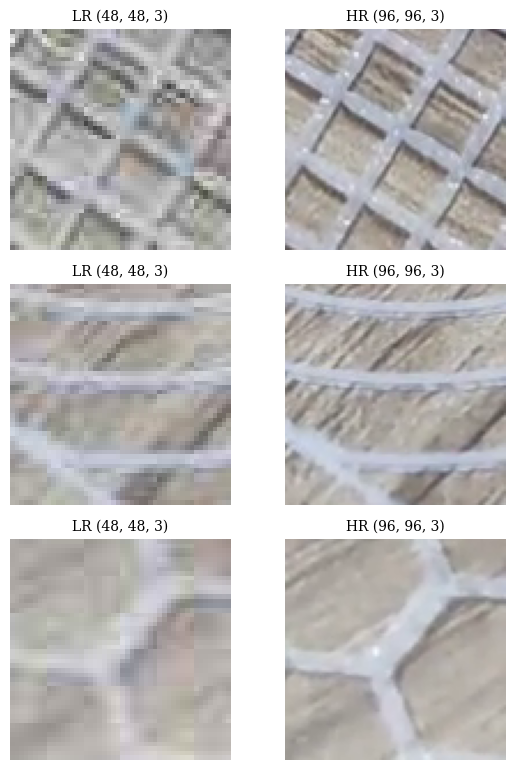

In [3]:
# What the model is actually fed: the LR patch and the HR patch it must
# reconstruct, whose side is EDSR_SCALE_FACTOR times larger.
_ = plot_patch_pairs(X_train, Y_train, count=3, seed=0)

In [4]:
model = EDSR()

model.setup_model(
    scale_factor=EDSR_SCALE_FACTOR, 
    num_res_blocks=16, 
    num_filters=64, 
    learning_rate=5e-5
)

Model: "EDSR"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 conv2d (Conv2D)                (None, None, None,   1792        ['input[0][0]']                  
                                64)                                                               
                                                                                                  
 conv2d_1 (Conv2D)              (None, None, None,   36928       ['conv2d[0][0]']                 
                                64)                                                            

In [5]:
# Train EDSR and capture callbacks for metrics
history, time_cb, mem_cb = model.fit(
    X_train, Y_train, X_val, Y_val, 
    batch_size=16, 
    epochs=50
)

Training on GPU: /physical_device:GPU:0
Epoch 1/50
729/729 [==============================] - 63s 68ms/step - loss: 0.1318 - psnr: 18.0228 - ssim: 0.3181 - val_loss: 0.0724 - val_psnr: 20.8933 - val_ssim: 0.3788 - lr: 5.0000e-05 - epoch_time_sec: 62.8637 - gpu_mean_current_mb: 1555.4652 - gpu_peak_mb: 2013.4700
Epoch 2/50
729/729 [==============================] - 48s 66ms/step - loss: 0.0579 - psnr: 22.8410 - ssim: 0.4944 - val_loss: 0.0577 - val_psnr: 22.9844 - val_ssim: 0.4718 - lr: 5.0000e-05 - epoch_time_sec: 48.0813 - gpu_mean_current_mb: 1736.7742 - gpu_peak_mb: 2140.9988
Epoch 3/50
729/729 [==============================] - 50s 69ms/step - loss: 0.0500 - psnr: 24.2331 - ssim: 0.5555 - val_loss: 0.0484 - val_psnr: 24.4967 - val_ssim: 0.5946 - lr: 5.0000e-05 - epoch_time_sec: 49.9987 - gpu_mean_current_mb: 1736.7742 - gpu_peak_mb: 2142.4348
Epoch 4/50
729/729 [==============================] - 51s 70ms/step - loss: 0.0447 - psnr: 25.2322 - ssim: 0.6047 - val_loss: 0.0487 - val_ps

KeyboardInterrupt: 

In [ ]:
del X_train, Y_train, X_val, Y_val  # Free memory
gc.collect()  # Force garbage collection to free memory

In [7]:
# Evaluates the run, saves the checkpoint and the metrics under one
# timestamp, so the reporting notebooks resolve a single run.
timestamp, run_dir, metrics = model.evaluate_and_save(
    X_test, Y_test, history, time_cb, mem_cb,
)

707/707 [==============================] - 12s 16ms/step - loss: 0.0013 - psnr: 31.3232 - ssim: 0.8418
Loss: 0.0013, PSNR: 31.32 dB, SSIM: 0.8418
